# lab 1

## NumPy basics

In [2]:
import numpy as np

In [38]:
# Сгенерируем случайный массив
np.random.seed(52)
arr = np.random.randint(0,100,12)

In [39]:
arr

array([28, 11, 13, 23, 86, 28, 32, 69, 11, 91, 35, 99], dtype=int32)

In [40]:
print(f"""
    min: {arr.min()}
    max: {arr.max()}
    min_index: {arr.argmin()}
    max_index: {arr.argmax()}""")


    min: 11
    max: 99
    min_index: 1
    max_index: 11


In [41]:
arr.mean()

np.float64(43.833333333333336)

In [42]:
arr[arr > 50]

array([86, 69, 91, 99], dtype=int32)

In [43]:
arr[2:5]

array([13, 23, 86], dtype=int32)

In [44]:
arr = arr.reshape(4, 3)
arr

array([[28, 11, 13],
       [23, 86, 28],
       [32, 69, 11],
       [91, 35, 99]], dtype=int32)

In [45]:
arr.T

array([[28, 23, 32, 91],
       [11, 86, 69, 35],
       [13, 28, 11, 99]], dtype=int32)

In [46]:
arr[1:3, 1:2]

array([[86],
       [69]], dtype=int32)

## OpenCV basics

Выделим зебру на картине

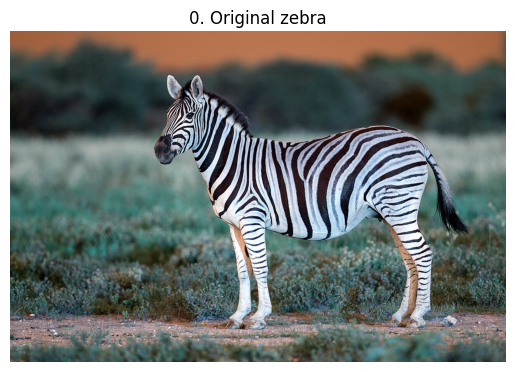

In [110]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_step(img, step_name):  
    plt.imshow(img, cmap='gray')
    plt.title(step_name)
    plt.axis('off')
    plt.show()

img_filename = 'zebra.png'
img = cv2.imread(img_filename)

show_step(img, '0. Original zebra')

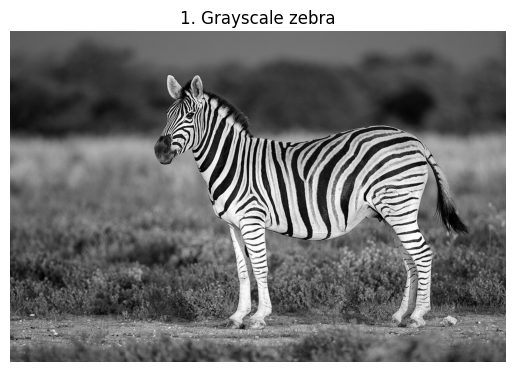

In [114]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show_step(gray, '1. Grayscale zebra')

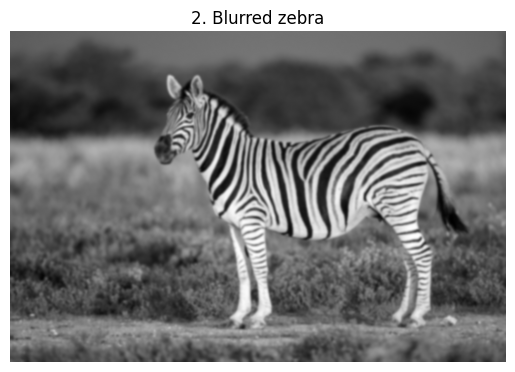

In [115]:
blurred = cv2.GaussianBlur(gray, (15, 15), 0)
show_step(blurred, '2. Blurred zebra')

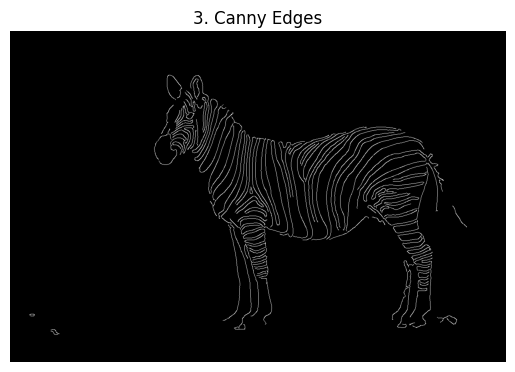

In [143]:
edged = cv2.Canny(blurred, 50, 150)
show_step(edged, '3. Canny Edges')

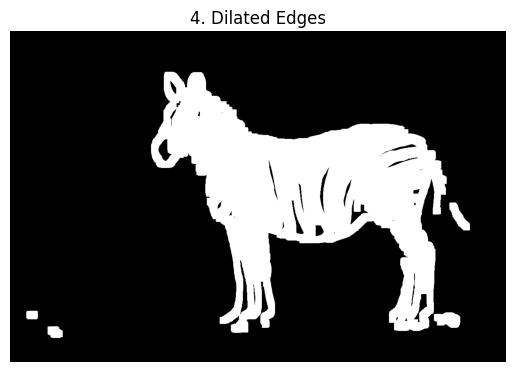

In [147]:
kernel = np.ones((17, 17), np.uint8)

dilated = cv2.dilate(edged, kernel, iterations=1)

show_step(dilated, '4. Dilated Edges')

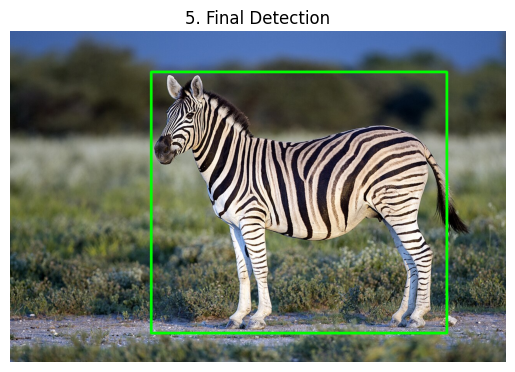

In [159]:
contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

zebra_contour = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(zebra_contour)

result = img.copy()
cv2.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 5)

show_step(cv2.cvtColor(result, cv2.COLOR_BGR2RGB), '5. Final Detection')

## OpenCV rectangle() implementation

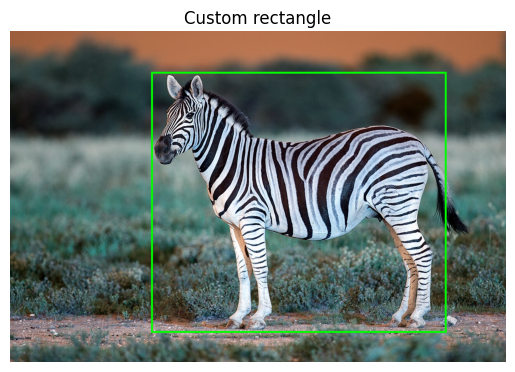

In [160]:
def rectangle(img, pt1, pt2, color, thickness=1):
    x1, y1 = pt1
    x2, y2 = pt2

    res = img.copy()
    h, w = res.shape[:2]

    x1 = np.clip(x1, 0, w)
    x2 = np.clip(x2, 0, w)
    y1 = np.clip(y1, 0, h)
    y2 = np.clip(y2, 0, h)


    res[y1:min(y1 + thickness, h), x1:x2] = color
    res[max(0, y2 - thickness):y2, x1:x2] = color
    res[y1:y2, x1:min(w, x1 + thickness)] = color
    res[y1:y2, max(0, x2 - thickness):x2] = color
    
    return res


final_img = rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 5)
show_step(final_img, 'Custom rectangle')